## **Bibliotecas** **para** **o** **Projeto** **atual** **e** **Visão** **Inicial** **dos** **Dados**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('TelecomX_tratado (1).csv')

print("Shape original:", df.shape)
print(df.info())

# 1) remover identificador
df_modelo = df.drop(columns=['customerID'], errors='ignore').copy()

# 2) corrigir variável alvo
df_modelo['Churn'] = df_modelo['Churn'].map({
    'Yes': 1,
    'No': 0,
    'Sim': 1,
    'Não': 0,
    'Nao': 0
})

# 3) converter coluna numérica salva como texto
df_modelo['account_Charges_Total'] = pd.to_numeric(
    df_modelo['account_Charges_Total'],
    errors='coerce'
)

# 4) remover linhas sem alvo
df_modelo = df_modelo.dropna(subset=['Churn'])

# 5) garantir tipo inteiro na variável alvo
df_modelo['Churn'] = df_modelo['Churn'].astype(int)

print("\nShape após limpeza:", df_modelo.shape)
print("\nChurn:")
print(df_modelo['Churn'].value_counts())
print(df_modelo['Churn'].value_counts(normalize=True))

# separar X e y
X = df_modelo.drop(columns='Churn')
y = df_modelo['Churn']


In [ ]:
!pip install imbalanced-learn

In [ ]:
df = pd.read_csv('TelecomX_tratado (1).csv')

In [ ]:
pd.read_csv('/content/TelecomX_tratado (1).csv')

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


## **Remoção** **de** **colunas** **e** **definições**

In [ ]:
# visão geral
print(df.shape)
display(df.head())
print(df.info())
print(df.isnull().sum().sort_values(ascending=False).head(10))

(7267, 21)


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [ ]:
colunas_irrelevantes = ['ID_Cliente', 'ID_Compra']  # ajuste conforme sua base
df_modelo = df.drop(columns=[col for col in colunas_irrelevantes if col in df.columns]).copy()

# garantir que a variável alvo esteja em formato binário
df_modelo['Churn'] = df_modelo['Churn'].replace({
    'Sim': 1, 'Não': 0, 'Nao': 0, 'Yes': 1, 'No': 0
})

print(df_modelo['Churn'].value_counts())
print(df_modelo['Churn'].value_counts(normalize=True))

Churn
0.0    5174
1.0    1869
Name: count, dtype: int64
Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64


/tmp/ipykernel_33924/3670002912.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_modelo['Churn'] = df_modelo['Churn'].replace({


## **Proporção** **da** **Evasão**



Churn
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


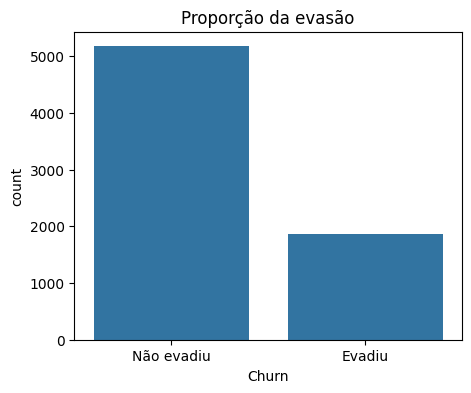

In [ ]:
proporcao = df_modelo['Churn'].value_counts(normalize=True) * 100
print(proporcao)

plt.figure(figsize=(5,4))
sns.countplot(data=df_modelo, x='Churn')
plt.title('Proporção da evasão')
plt.xticks([0,1], ['Não evadiu', 'Evadiu'])
plt.show()

In [ ]:
X = df_modelo.drop(columns='Churn')
y = df_modelo['Churn']

X = pd.get_dummies(X, drop_first=True)

print(X.shape)
display(X.head())

(7267, 13825)


,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,account_Charges_Total_995.35,account_Charges_Total_996.45,account_Charges_Total_996.85,account_Charges_Total_996.95,account_Charges_Total_997.65,account_Charges_Total_997.75,account_Charges_Total_998.1,account_Charges_Total_999.45,account_Charges_Total_999.8,account_Charges_Total_999.9
0,0,9,65.6,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,9,59.9,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,4,73.9,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,13,98.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,3,83.9,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## **Encoding**

In [ ]:
X = df_modelo.drop(columns='Churn')
y = df_modelo['Churn']

X = pd.get_dummies(X, drop_first=True)

print(X.shape)
display(X.head())

(7267, 13825)


,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,customerID_0014-BMAQU,...,account_Charges_Total_995.35,account_Charges_Total_996.45,account_Charges_Total_996.85,account_Charges_Total_996.95,account_Charges_Total_997.65,account_Charges_Total_997.75,account_Charges_Total_998.1,account_Charges_Total_999.45,account_Charges_Total_999.8,account_Charges_Total_999.9
0,0,9,65.6,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,9,59.9,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,4,73.9,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,13,98.0,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,3,83.9,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
print(y.value_counts())
print(y.value_counts(normalize=True))

Churn
0.0    5174
1.0    1869
Name: count, dtype: int64
Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64


## **Análise** **de** **correlação** **e** **Seleção** **de** **Variáveis**

In [ ]:
df_corr = pd.concat([X, y], axis=1)

print(df_corr.shape)
print(df_corr.columns.tolist()[-10:])
print(df_corr['Churn'].dtype)

(7267, 13826)
['account_Charges_Total_996.45', 'account_Charges_Total_996.85', 'account_Charges_Total_996.95', 'account_Charges_Total_997.65', 'account_Charges_Total_997.75', 'account_Charges_Total_998.1', 'account_Charges_Total_999.45', 'account_Charges_Total_999.8', 'account_Charges_Total_999.9', 'Churn']
float64


In [ ]:
corr_Churn = X.apply(lambda col: col.corr(y))
corr_Churn = corr_Churn.dropna().sort_values(key=abs, ascending=False)

print(corr_Churn.head(15))

customer_tenure                                 -0.352229
internet_InternetService_Fiber optic             0.308020
account_Contract_Two year                       -0.302253
account_PaymentMethod_Electronic check           0.301919
internet_OnlineSecurity_No internet service     -0.227890
internet_OnlineBackup_No internet service       -0.227890
internet_StreamingMovies_No internet service    -0.227890
internet_TechSupport_No internet service        -0.227890
internet_StreamingTV_No internet service        -0.227890
internet_DeviceProtection_No internet service   -0.227890
internet_InternetService_No                     -0.227890
account_Charges_Monthly                          0.193356
account_PaperlessBilling_Yes                     0.191825
account_Contract_One year                       -0.177820
internet_OnlineSecurity_Yes                     -0.171226
dtype: float64


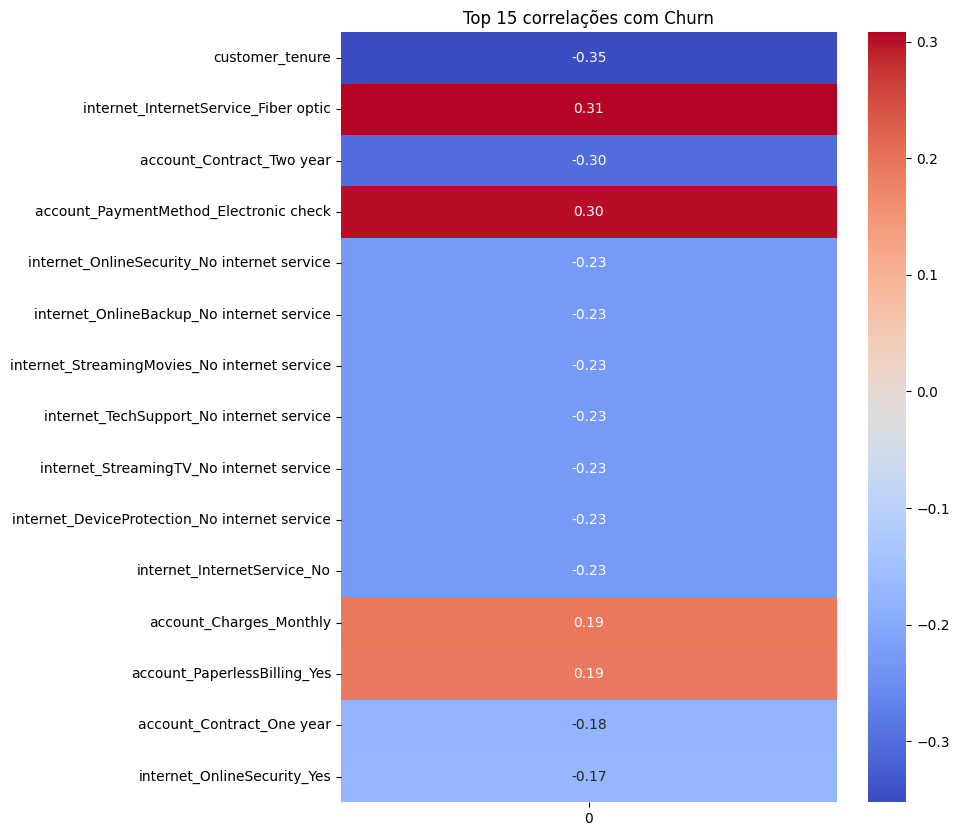

In [ ]:
plt.figure(figsize=(8,10))
sns.heatmap(corr_Churn.head(15).to_frame(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Top 15 correlações com Churn')
plt.show()

In [ ]:
variaveis_selecionadas = corr_Churn[abs(corr_Churn) > 0.05].index
X = X[variaveis_selecionadas]

print(f'Número de variáveis selecionadas: {X.shape[1]}')
print(X.columns.tolist())

Número de variáveis selecionadas: 25
['customer_tenure', 'internet_InternetService_Fiber optic', 'account_Contract_Two year', 'account_PaymentMethod_Electronic check', 'internet_OnlineSecurity_No internet service', 'internet_OnlineBackup_No internet service', 'internet_StreamingMovies_No internet service', 'internet_TechSupport_No internet service', 'internet_StreamingTV_No internet service', 'internet_DeviceProtection_No internet service', 'internet_InternetService_No', 'account_Charges_Monthly', 'account_PaperlessBilling_Yes', 'account_Contract_One year', 'internet_OnlineSecurity_Yes', 'internet_TechSupport_Yes', 'customer_Dependents_Yes', 'customer_SeniorCitizen', 'customer_Partner_Yes', 'account_PaymentMethod_Credit card (automatic)', 'account_PaymentMethod_Mailed check', 'internet_OnlineBackup_Yes', 'internet_DeviceProtection_Yes', 'internet_StreamingTV_Yes', 'internet_StreamingMovies_Yes']


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

# **Correção** **de** **Erro**

In [ ]:
df_modelo = df_modelo.dropna(subset=['Churn'])
df_modelo = df_modelo.dropna(subset=['account_Charges_Total'])

df_modelo['Churn'] = df_modelo['Churn'].astype(int)

X = df_modelo.drop(columns='Churn')
y = df_modelo['Churn']

X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.isna().sum()[X.isna().sum() > 0])

(7043, 13601)
Series([], dtype: int64)


# **Análises** **Direcionadas**

In [ ]:
df_graficos = df_modelo.rename(columns={
    'customer_tenure': 'tempo_contrato',
    'account_Charges_Total': 'total_gasto'
})

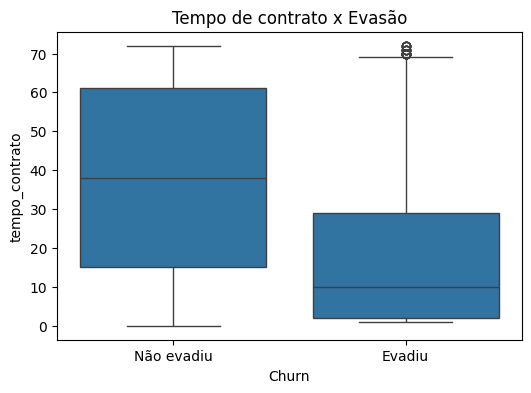

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_graficos, x='Churn', y='tempo_contrato')
plt.title('Tempo de contrato x Evasão')
plt.xticks([0,1], ['Não evadiu', 'Evadiu'])
plt.show()

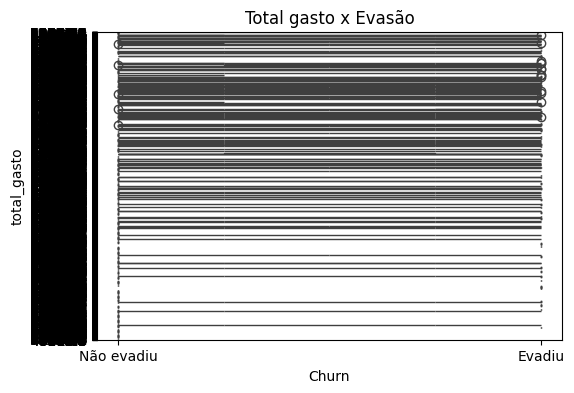

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_graficos, x='Churn', y='total_gasto')
plt.title('Total gasto x Evasão')
plt.xticks([0,1], ['Não evadiu', 'Evadiu'])
plt.show()

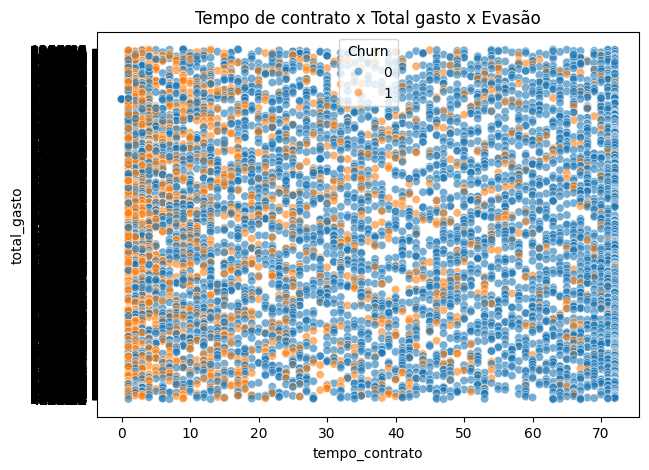

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_graficos, x='tempo_contrato', y='total_gasto', hue='Churn', alpha=0.6)
plt.title('Tempo de contrato x Total gasto x Evasão')
plt.show()

# **Treino**, **Teste**, **Padronização** **e** **Balanceamento**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Treino:', X_train.shape, y_train.shape)
print('Teste:', X_test.shape, y_test.shape)

# balanceamento com SMOTE apenas no treino
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Antes do balanceamento:')
print(y_train.value_counts())

print('\nDepois do balanceamento:')
print(y_train_bal.value_counts())

Treino: (5634, 13601) (5634,)
Teste: (1409, 13601) (1409,)
Antes do balanceamento:
Churn
0    4139
1    1495
Name: count, dtype: int64

Depois do balanceamento:
Churn
0    4139
1    4139
Name: count, dtype: int64


# **Regressão** **Logística**

In [ ]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_lr.fit(X_train_bal, y_train_bal)

y_pred_lr = pipeline_lr.predict(X_test)

REGRESSÃO LOGÍSTICA
Acurácia: 0.6990773598296665
Precisão: 0.4622356495468278
Recall: 0.8181818181818182
F1-score: 0.5907335907335908

Relatório:
               precision    recall  f1-score   support

           0       0.91      0.66      0.76      1035
           1       0.46      0.82      0.59       374

    accuracy                           0.70      1409
   macro avg       0.69      0.74      0.68      1409
weighted avg       0.79      0.70      0.72      1409



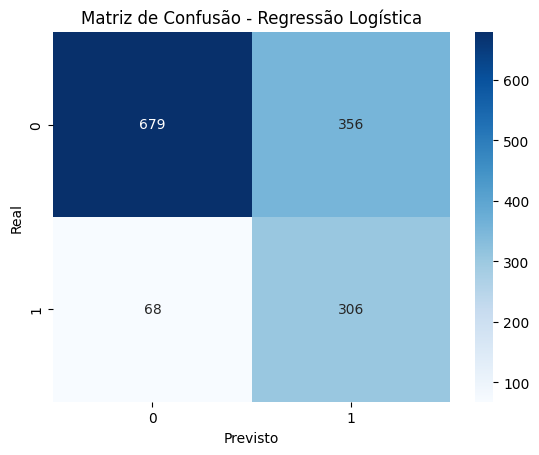

In [ ]:
print('REGRESSÃO LOGÍSTICA')
print('Acurácia:', accuracy_score(y_test, y_pred_lr))
print('Precisão:', precision_score(y_test, y_pred_lr))
print('Recall:', recall_score(y_test, y_pred_lr))
print('F1-score:', f1_score(y_test, y_pred_lr))
print('\nRelatório:\n', classification_report(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# **Random** **Forest**

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_bal, y_train_bal)

y_pred_rf = rf.predict(X_test)

RANDOM FOREST
Acurácia: 0.78708303761533
Precisão: 0.6069364161849711
Recall: 0.5614973262032086
F1-score: 0.5833333333333334

Relatório:
               precision    recall  f1-score   support

           0       0.85      0.87      0.86      1035
           1       0.61      0.56      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.79      0.78      1409



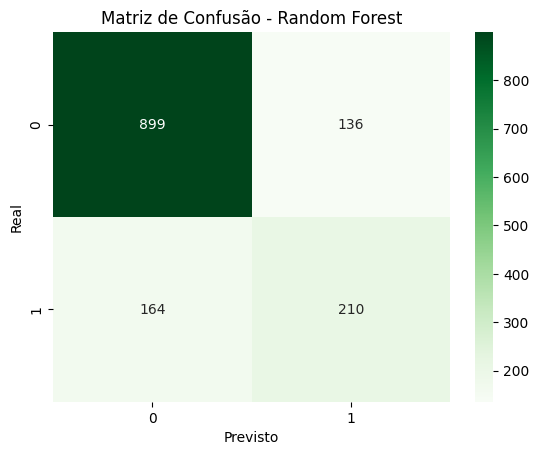

In [ ]:
print('RANDOM FOREST')
print('Acurácia:', accuracy_score(y_test, y_pred_rf))
print('Precisão:', precision_score(y_test, y_pred_rf))
print('Recall:', recall_score(y_test, y_pred_rf))
print('F1-score:', f1_score(y_test, y_pred_rf))
print('\nRelatório:\n', classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

# **Comparação** **dos** **Modelos**

In [ ]:
resultados = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Random Forest'],
    'Acurácia': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precisão': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

display(resultados.sort_values(by='F1-score', ascending=False))

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,0.699077,0.462236,0.818182,0.590734
1,Random Forest,0.787083,0.606936,0.561497,0.583333


# **Verificação dos** **Indícios** **de** **Overfitting**/**Underfitting**

In [ ]:
# regressão logística
acc_train_lr = accuracy_score(y_train_bal, pipeline_lr.predict(X_train_bal))
acc_test_lr = accuracy_score(y_test, y_pred_lr)

# random forest
acc_train_rf = accuracy_score(y_train_bal, rf.predict(X_train_bal))
acc_test_rf = accuracy_score(y_test, y_pred_rf)

print('Regressão Logística - treino:', acc_train_lr, '| teste:', acc_test_lr)
print('Random Forest - treino:', acc_train_rf, '| teste:', acc_test_rf)

Regressão Logística - treino: 1.0 | teste: 0.6990773598296665
Random Forest - treino: 1.0 | teste: 0.78708303761533


# **CONCLUSÃO**



A análise preditiva realizada permitiu identificar padrões relevantes associados à evasão de clientes e avaliar o desempenho de diferentes modelos de classificação. Após a preparação da base, tratamento das variáveis e balanceamento das classes no conjunto de treino, foi possível observar que clientes com menor tempo de contrato e menor gasto total apresentaram maior propensão ao rompimento de contrato.
Entre os modelos testados, o Random Forest apresentou melhor desempenho geral, com maior acurácia e precisão, enquanto a Regressão Logística se destacou no recall, mostrando maior capacidade de identificar clientes que realmente evadem. Esse resultado indica que a escolha do modelo depende do objetivo da análise: se a prioridade for desempenho global, o Random Forest se mostra mais adequado; se o foco for detectar o maior número possível de clientes em risco, a Regressão Logística pode ser uma alternativa melhor.
A comparação entre os desempenhos do treino e do teste indicou sinais de sobreajuste, reforçando a importância de avaliar a generalização dos modelos. O estudo demonstrou que técnicas de machine learning podem oferecer suporte valioso à tomada de decisão, permitindo à empresa antecipar riscos de evasão e direcionar estratégias de retenção de forma mais assertada.

Este projeto de análise foi desenvolvido para fins de estudo, fixação do conteúdo pedagógico e avaliação do aprendizado, como parte da proposta educacional do programa ONE + Alura.